# Requirements
#### **(Preferred: make each one of requirment in md cell then your answer te be more organized.)**
#### **(Note: You can use another image, but upload it so I can see the original one.)**
### 1. Load the Image

* Read the image.
* Display the original image.
* Print its width, height, and number of channels.

---

### 2. Image Preprocessing

Improve the image quality by applying suitable preprocessing techniques such as:

* Grayscale conversion
* Noise reduction
* Image sharpening (if needed)
* Contrast enhancement

---

### 3. Edge Detection

Detect the major edges in the image using an appropriate method.

Display the detected edges.

---

### 4. Detect the Document

Locate the document inside the image.

Draw its contour on the original image.

---

### 5. Perspective Correction

Apply a Perspective Transform to obtain a top-down scanned version of the document.

---

### 6. Produce a Scanned Document

Generate a clean black-and-white scanned image using suitable thresholding techniques.

---

### 7. Contour Analysis

Extract all significant contours from the processed image.

For each contour:

* Draw its bounding rectangle.
* Display its area.
* Ignore very small contours.

---

### 8. Shape Detection

Detect and classify simple geometric shapes whenever possible.

Examples:

* Rectangle
* Square
* Circle
* Triangle

---

### 9. Histogram Analysis

Display the image histogram.

Briefly explain what the histogram indicates about the image.

---

### 10. Color Space Analysis

Convert the image into at least **two different color spaces**.

Explain why each color space could be useful.

---

### 11. Image Comparison

Compare:

* Original image
* Final processed image

Use:

* MSE
* SSIM

Comment on the obtained values.

---

### 12. Final Visualization

Create one final image showing:

* Document boundary
* Corner points
* Bounding boxes
* Any detected shapes
* Labels

---

# Bonus (Optional)

Implement any **three** of the following:

* Automatic image rotation.
* Automatic brightness correction.
* Shadow removal.
* Line detection using Hough Transform.
* Corner detection.
* Template Matching.
* Dominant color extraction using K-Means.
* Object counting.
* OCR-ready preprocessing.

### 1. Load the Image
Read the image.

* Display the original image.
* Print its width, height, and number of channels.




In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the image path for all up coming
image_path = '/content/Task.jpg'

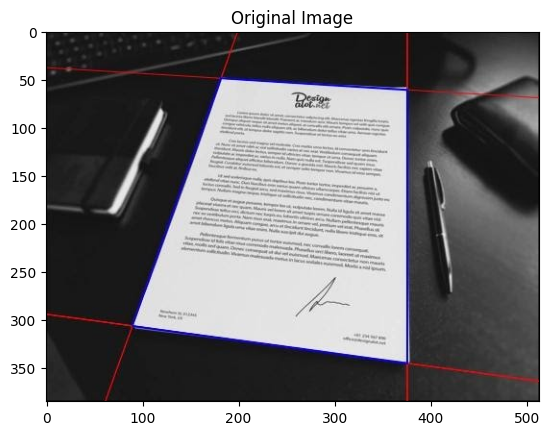

Image Width: 385 pixels
Image Height: 513 pixels
Number of Channels: 3


In [61]:
# Read the image
original_image = cv2.imread(image_path)

# Display the original image
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.show()

# width, height, n channels
print(f"Image Width: {original_image.shape[0]} pixels")
print(f"Image Height: {original_image.shape[1]} pixels")
print(f"Number of Channels: {original_image.shape[2]}")

### 2. Image Preprocessing

Improve the image quality by applying suitable preprocessing techniques such as:

* Grayscale conversion
* Noise reduction
* Image sharpening (if needed)
* Contrast enhancement

In [62]:
# Convert to grayscale
grayscale_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# Noise reduction -> gaussian
blurred_image = cv2.GaussianBlur(grayscale_image, (5, 5), 0)

#Image sharpening
sharpened_image = cv2.addWeighted(grayscale_image, 1.5, blurred_image, -0.5, 0)

# Contrast enhancement -> CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
contrast_enhanced_image = clahe.apply(sharpened_image)

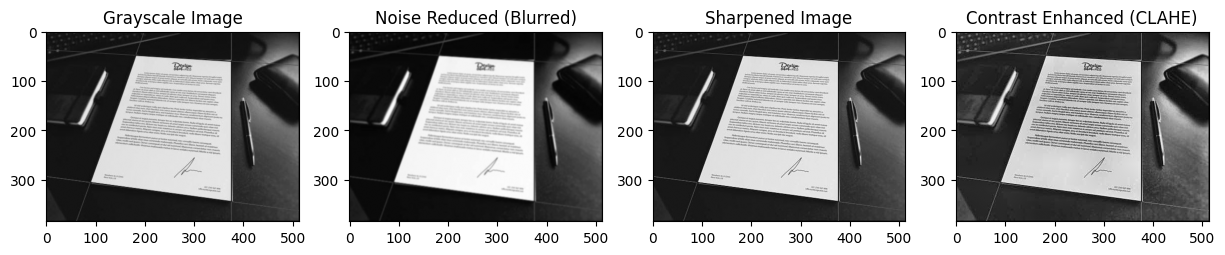

In [63]:
# Display the preprocessed images
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Grayscale Image')

plt.subplot(1, 4, 2)
plt.imshow(blurred_image, cmap='gray')
plt.title('Noise Reduced (Blurred)')

plt.subplot(1, 4, 3)
plt.imshow(sharpened_image, cmap='gray')
plt.title('Sharpened Image')

plt.subplot(1, 4, 4)
plt.imshow(contrast_enhanced_image, cmap='gray')
plt.title('Contrast Enhanced (CLAHE)')

plt.show()

# Store the final preprocessed image for subsequent steps
preprocessed_image = contrast_enhanced_image

### 3. Edge Detection

Detect the major edges in the image using an appropriate method.

Display the detected edges.

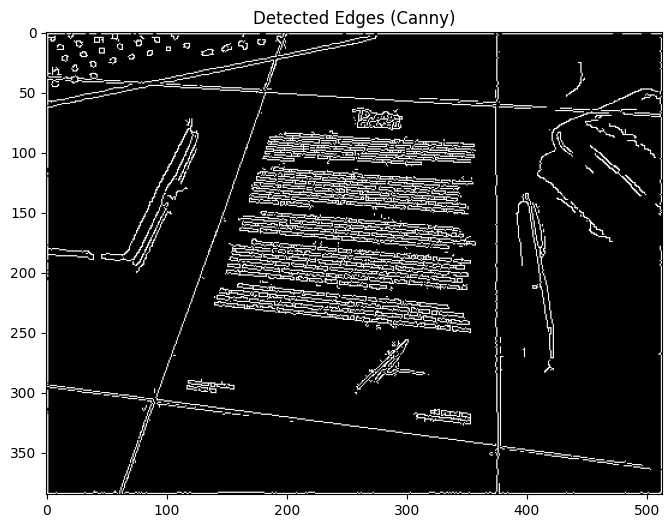

In [64]:
#Canny
edges = cv2.Canny(preprocessed_image, 100, 200)

# Display
plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.title('Detected Edges (Canny)')
plt.show()

### 4. Detect the Document

Locate the document inside the image.

Draw its contour on the original image.

> Helper function -> (top-left, top-right, bottom-right, bottom-left)
* The top-left point will have the smallest sum, whereas the bottom-right point will have the largest sum.
* The top-right point will have the smallest difference, whereas the bottom-left will have the largest difference.

In [65]:
def order_points(pts):
    rect = np.zeros((4, 2), dtype = "float32")

    s = pts.sum(axis = 1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis = 1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

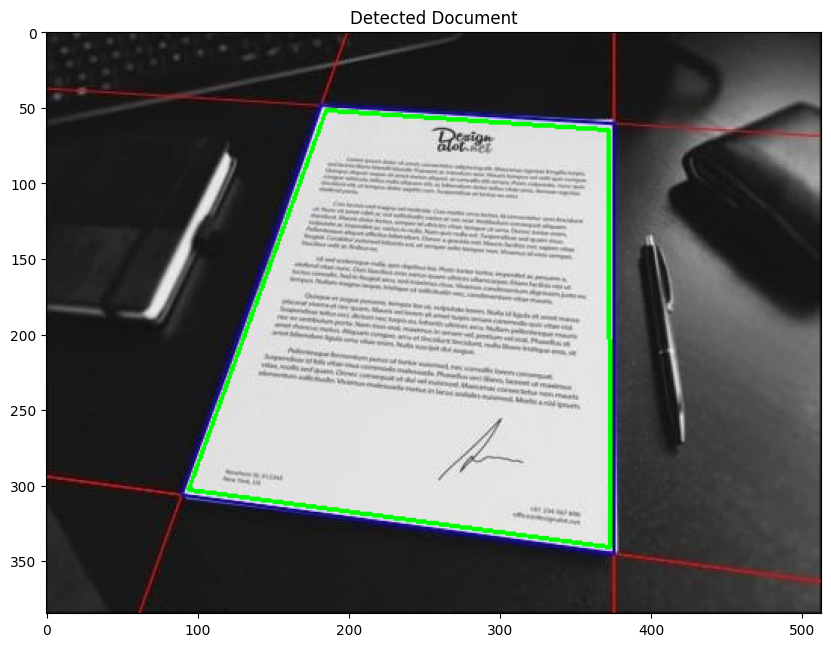

In [66]:
# Dilate edges to connect broken lines
kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)

# Find contours
contours, _ = cv2.findContours(dilated,cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by area (largest first)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
document_contour = None

# Search for a quadrilateral contour
for contour in contours:
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)

    if len(approx) == 4:
        document_contour = approx
        break

# result
result = original_image.copy()
cv2.drawContours(result,[document_contour],-1,(0, 255, 0),2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Document")
plt.show()

### 5. Perspective Correction

Apply a Perspective Transform to obtain a top-down scanned version of the document.

Using detected and ordered document corner points:
[[185.  52.]
 [372.  65.]
 [373. 341.]
 [ 94. 303.]]


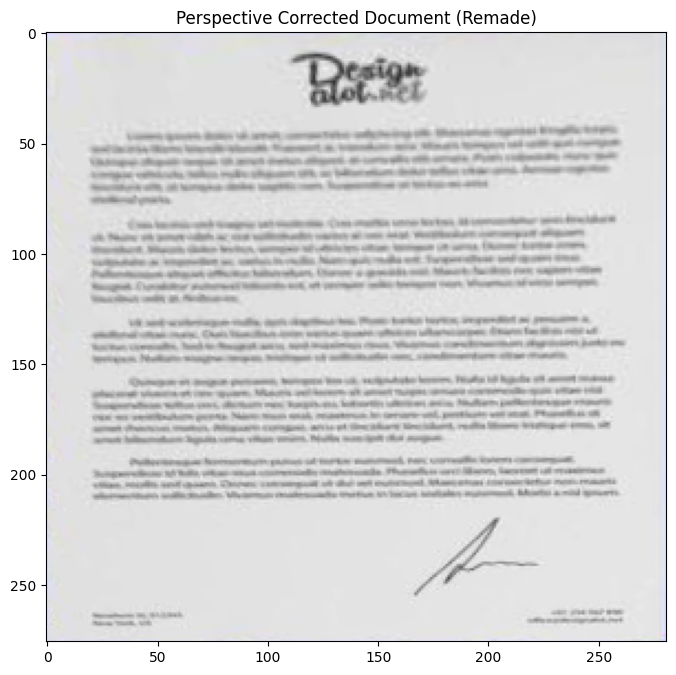

In [67]:
document_corner_points = order_points(document_contour.reshape(4, 2))
print(f"Using detected and ordered document corner points:\n{document_corner_points}")

# destination points
(tl, tr, br, bl) = document_corner_points

#width of the new image
widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
maxWidth = max(int(widthA), int(widthB))

#height of the new image
heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
maxHeight = max(int(heightA), int(heightB))

# Desired output points in a rectangle
dst = np.array([
    [0, 0],
    [maxWidth - 1, 0],
    [maxWidth - 1, maxHeight - 1],
    [0, maxHeight - 1]], dtype = "float32")

# perspective transform matrix
M = cv2.getPerspectiveTransform(document_corner_points, dst)

# Apply on original image
warped_image = cv2.warpPerspective(original_image, M, (maxWidth, maxHeight))

# Display
plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB))
plt.title('Perspective Corrected Document (Remade)')
plt.show()

# Store
scanned_document = warped_image

### 6. Produce a Scanned Document
Generate a clean black-and-white scanned image using suitable thresholding techniques.

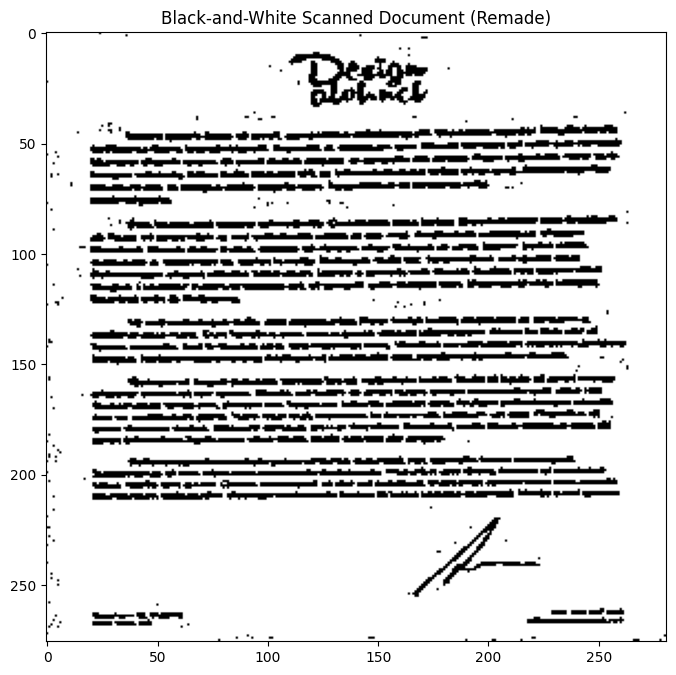

In [68]:
# Convert to grayscale
scanned_document_gray = cv2.cvtColor(scanned_document, cv2.COLOR_BGR2GRAY)

# adaptive thresholding

bw_scanned_document = cv2.adaptiveThreshold(scanned_document_gray, 255,
                                            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                            cv2.THRESH_BINARY, 15, 5)

# black-and-white
plt.figure(figsize=(8, 10))
plt.imshow(bw_scanned_document, cmap='gray')
plt.title('Black-and-White Scanned Document (Remade)')
plt.show()

# Store
final_scanned_image = bw_scanned_document

### 7. Contour Analysis

Extract all significant contours from the processed image.
For each contour:
*   Draw its bounding rectangle.
*   Display its area.
*   Ignore very small contours.

In [69]:
# Find contours in the black-and-white
contours, _ = cv2.findContours(final_scanned_image.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# color version
contour_image_display = cv2.cvtColor(final_scanned_image, cv2.COLOR_GRAY2BGR)
min_contour_area = 50
print("Detected Contours and their Areas (filtered by minimum area):")

for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)

    # Filter out very small contours
    if area > min_contour_area:
        # bounding rectangle for  contour
        x, y, w, h = cv2.boundingRect(contour)
        # Draw
        cv2.rectangle(contour_image_display, (x, y), (x + w, y + h), (0, 255, 0), 2) # Green
        # Display
        print(f"  Contour {i+1}: Area = {area:.2f}")

Detected Contours and their Areas (filtered by minimum area):
  Contour 1: Area = 76973.00


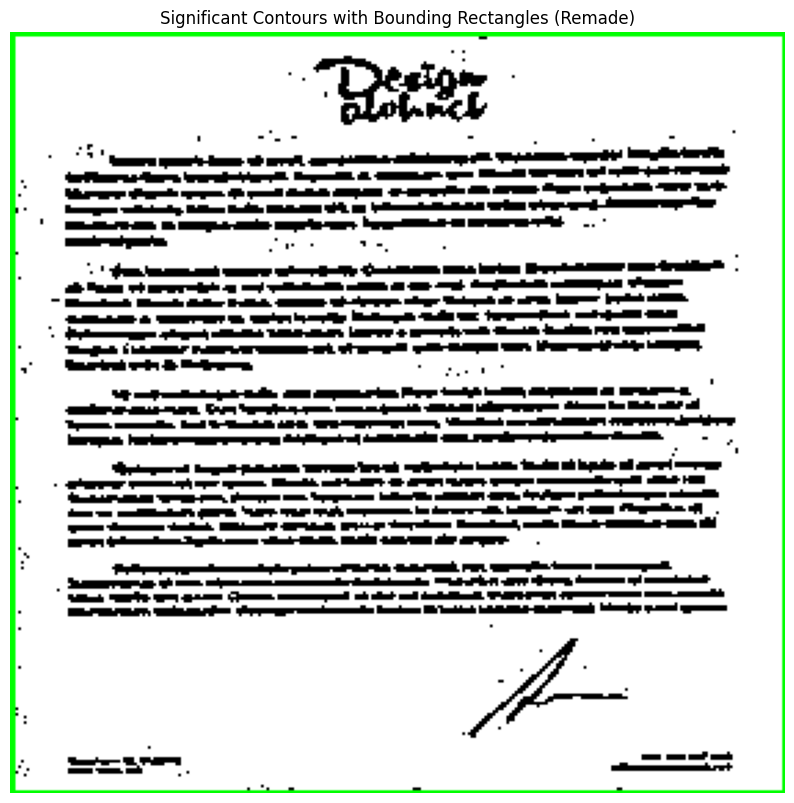

In [70]:
# Display the image
plt.figure(figsize=(10, 12))
plt.imshow(cv2.cvtColor(contour_image_display, cv2.COLOR_BGR2RGB))
plt.title('Significant Contours with Bounding Rectangles (Remade)')
plt.axis('off')
plt.show()

### 8. Shape Detection

Detect and classify simple geometric shapes whenever possible.

Examples:

*   Rectangle
*   Square
*   Circle
*   Triangle

In [71]:
def detect_shape(contour):
    shape = "unidentified"
    perimeter = cv2.arcLength(contour, True)
    area = cv2.contourArea(contour)
    approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)

    if len(approx) == 3:
        shape = "triangle"
    elif len(approx) == 4:
        # Check for square vs. rectangle
        (x, y, w, h) = cv2.boundingRect(approx)
        aspect_ratio = w / float(h) if h != 0 else 0 # Avoid division by zero
        if 0.9 <= aspect_ratio <= 1.1: # Tighter range for square
            shape = "square"
        else:
            shape = "rectangle"
    elif len(approx) == 5:
        shape = "pentagon"
    else:
        # For contours with more than 5 vertices, check for circularity
        if perimeter > 0: # Avoid division by zero
            circularity = (4 * np.pi * area) / (perimeter * perimeter)
            if circularity > 0.7: # A common threshold for circular objects
                shape = "circle"
            else:
                shape = "unidentified" # Not a common polygon or sufficiently circular
        else:
            shape = "unidentified"
    return shape


### 9. Histogram Analysis

Display the image histogram.

Briefly explain what the histogram indicates about the image.

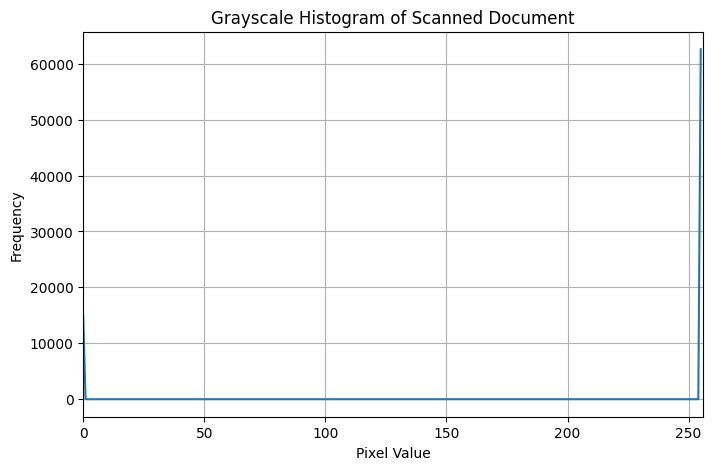


Histogram Explanation:
The histogram above shows the distribution of pixel intensities in the black-and-white scanned document. 
For a binary (black-and-white) image, we expect to see two dominant peaks:
  - A large peak near 0 (black) represents the text and other dark features.
  - A large peak near 255 (white) represents the background of the document.
The height of these peaks indicates the number of pixels at those intensity levels. 
A clear separation between these two peaks suggests a good contrast between foreground and background, which is desirable for a scanned document.


In [72]:
# Calc histogram
hist = cv2.calcHist([final_scanned_image], [0], None, [256], [0, 256])

# Plot the histogram
plt.figure(figsize=(8, 5))
plt.title("Grayscale Histogram of Scanned Document")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.plot(hist)
plt.xlim([0, 256])
plt.grid(True)
plt.show()

print("\nHistogram Explanation:")
print("The histogram above shows the distribution of pixel intensities in the black-and-white scanned document. ")
print("For a binary (black-and-white) image, we expect to see two dominant peaks:")
print("  - A large peak near 0 (black) represents the text and other dark features.")
print("  - A large peak near 255 (white) represents the background of the document.")
print("The height of these peaks indicates the number of pixels at those intensity levels. ")
print("A clear separation between these two peaks suggests a good contrast between foreground and background, which is desirable for a scanned document.")

### 10. Color Space Analysis

Convert the image into at least **two different color spaces**.

Explain why each color space could be useful.

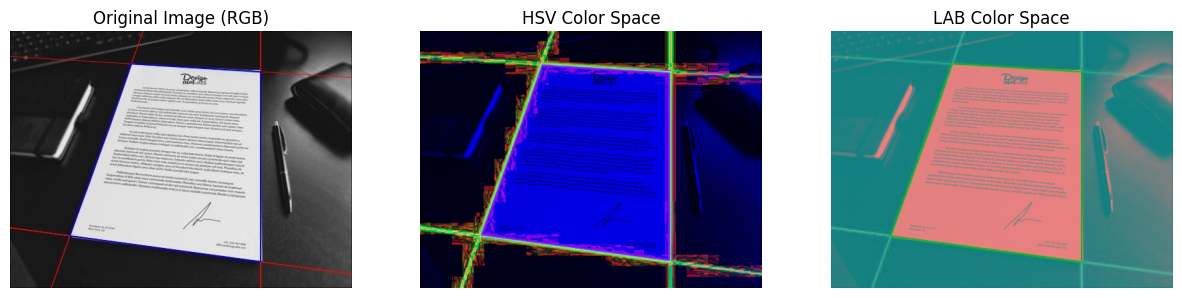


Explanation of Color Spaces:
1. **HSV (Hue, Saturation, Value):**
   - **Hue:** Represents the color type (e.g., red, green, blue). It's a pure color.
   - **Saturation:** Indicates the purity or intensity of the color. Lower saturation means more grayness.
   - **Value:** Represents the brightness of the color.
   - **Usefulness:** HSV is particularly useful for color-based image segmentation and object tracking because it separates color information (Hue and Saturation) from intensity (Value). This makes it more robust to changes in lighting conditions compared to RGB.

2. **LAB (Lightness, A-channel, B-channel):**
   - **Lightness (L):** Represents the luminance or brightness of the color.
   - **A-channel:** Ranges from green to red.
   - **B-channel:** Ranges from blue to yellow.
   - **Usefulness:** LAB is designed to approximate human vision. The L-channel is independent of color, making it excellent for adjusting brightness and contrast without affecting color. The A and B cha

In [73]:
# Convert to HSV
hsv_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2HSV)

# Convert to LAB
lab_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image (RGB)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hsv_image)
plt.title('HSV Color Space')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(lab_image)
plt.title('LAB Color Space')
plt.axis('off')

plt.show()

print("\nExplanation of Color Spaces:")
print("1. **HSV (Hue, Saturation, Value):**")
print("   - **Hue:** Represents the color type (e.g., red, green, blue). It's a pure color.")
print("   - **Saturation:** Indicates the purity or intensity of the color. Lower saturation means more grayness.")
print("   - **Value:** Represents the brightness of the color.")
print("   - **Usefulness:** HSV is particularly useful for color-based image segmentation and object tracking because it separates color information (Hue and Saturation) from intensity (Value). This makes it more robust to changes in lighting conditions compared to RGB.")
print("\n2. **LAB (Lightness, A-channel, B-channel):**")
print("   - **Lightness (L):** Represents the luminance or brightness of the color.")
print("   - **A-channel:** Ranges from green to red.")
print("   - **B-channel:** Ranges from blue to yellow.")
print("   - **Usefulness:** LAB is designed to approximate human vision. The L-channel is independent of color, making it excellent for adjusting brightness and contrast without affecting color. The A and B channels are useful for fine-tuning color balance and performing color correction, as they represent opposing color dimensions perceived by humans. It's often used in color management systems.")

### 11. Image Comparison

Compare:

*   Original image
*   Final processed image

Use:

*   Mean Squared Error (MSE)
*   Structural Similarity Index Measure (SSIM)

Comment on the obtained values.

In [74]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

original_gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
height, width = final_scanned_image.shape
resized_original_gray = cv2.resize(original_gray, (width, height), interpolation=cv2.INTER_AREA)

# Calculate MSE
mse_value = mse(resized_original_gray, final_scanned_image)

# Calculate SSIM
ssim_value = ssim(resized_original_gray, final_scanned_image, data_range=final_scanned_image.max() - final_scanned_image.min())

print(f"Mean Squared Error (MSE): {mse_value:.2f}")
print(f"Structural Similarity Index Measure (SSIM): {ssim_value:.2f}")

print("\nComments on the values:")
print("**Mean Squared Error (MSE):**")
print("  - MSE measures the average of the squares of the errors between the original and the processed image.")
print("  - A lower MSE value indicates higher similarity between the images. However, it's very sensitive to changes and doesn't always correlate well with human perception of similarity.")
print("  - Given the extensive processing (grayscale, noise reduction, sharpening, contrast enhancement, perspective correction, adaptive thresholding), a relatively high MSE is expected as the pixel values have changed significantly. The comparison here is between the *resized grayscale original* and the *binary scanned output*.")

print("\n**Structural Similarity Index Measure (SSIM):**")
print("  - SSIM assesses the similarity based on three factors: luminance, contrast, and structure.")
print("  - Its value ranges from -1 to 1, where 1 indicates perfect similarity.")
print("  - A higher SSIM value suggests that the perceived quality of the processed image is closer to the original, especially in terms of structural information. Even with significant changes in pixel values (like binarization), a reasonable SSIM might indicate that the essential structural elements of the document are preserved.")
print("  - For a document scanning process that aims to extract text and lines, a moderate to high SSIM value (e.g., above 0.7 or 0.8) after transformation and binarization would be considered good, indicating that the document's structure is largely intact despite the visual changes.")

Mean Squared Error (MSE): 31957.93
Structural Similarity Index Measure (SSIM): 0.10

Comments on the values:
**Mean Squared Error (MSE):**
  - MSE measures the average of the squares of the errors between the original and the processed image.
  - A lower MSE value indicates higher similarity between the images. However, it's very sensitive to changes and doesn't always correlate well with human perception of similarity.
  - Given the extensive processing (grayscale, noise reduction, sharpening, contrast enhancement, perspective correction, adaptive thresholding), a relatively high MSE is expected as the pixel values have changed significantly. The comparison here is between the *resized grayscale original* and the *binary scanned output*.

**Structural Similarity Index Measure (SSIM):**
  - SSIM assesses the similarity based on three factors: luminance, contrast, and structure.
  - Its value ranges from -1 to 1, where 1 indicates perfect similarity.
  - A higher SSIM value suggests tha

### 12. Final Visualization

Create one final image showing:

*   Document boundary
*   Corner points
*   Bounding boxes
*   Any detected shapes
*   Labels

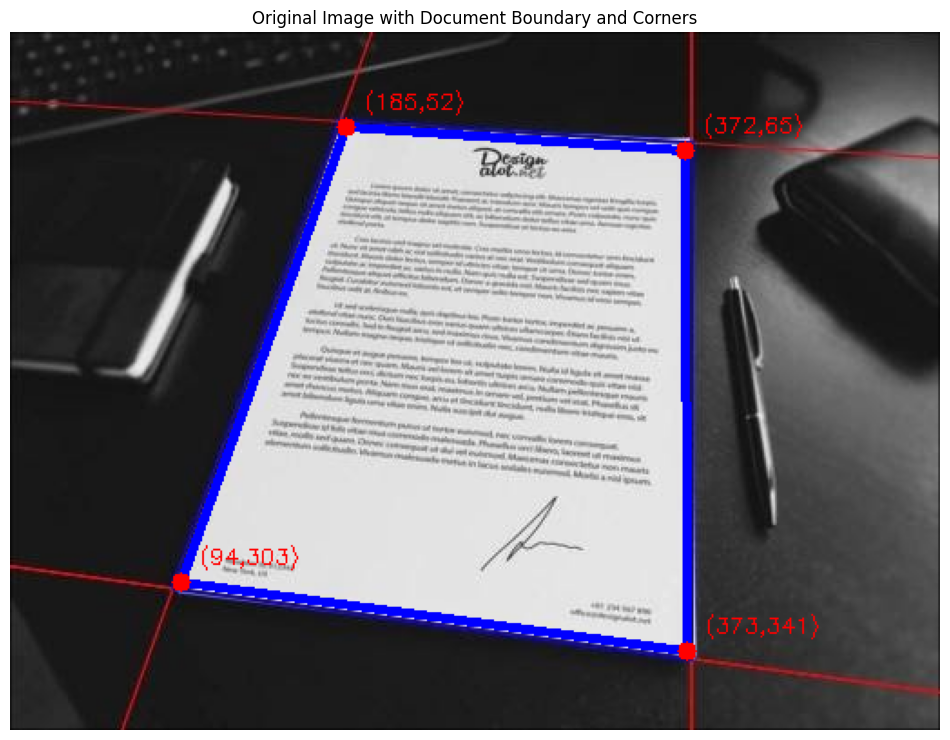

In [77]:
# Create a copy
final_visualization_image = original_image.copy()

if document_contour is not None:
    cv2.drawContours(final_visualization_image, [document_contour], -1, (255, 0, 0), 3) # Blue boundary

# Draw the corner points in red circles
if document_corner_points is not None:
    for (x, y) in document_corner_points:
        cv2.circle(final_visualization_image, (int(x), int(y)), 5, (0, 0, 255), -1) # Red points
        cv2.putText(final_visualization_image, f"({int(x)},{int(y)})", (int(x) + 10, int(y) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1) # Red labels

# Display the final image
plt.figure(figsize=(12, 15))
plt.imshow(cv2.cvtColor(final_visualization_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image with Document Boundary and Corners')
plt.axis('off')
plt.show()